Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import transformers
transformers.logging.set_verbosity_error()

In [ ]:
!pip install -U bitsandbytes transformers accelerate peft trl

Load raw JSON dataset from Drive

In [ ]:
import json
path = "/content/drive/MyDrive/Algebra_Model/Data/algebra_dataset.json"

with open(path, "r") as f:
    data = json.load(f)

Load and Format Raw Dataset

In [ ]:
formatted_data = []

for item in data:
    theorem = item["theorem"]
    proof = item["proof"]

    prompt = f"Prove the following algebraic identity:\n{theorem}\nShow each algebra step clearly."
    completion = proof

    formatted_data.append({
        "prompt": prompt,
        "completion": completion
    })

len(formatted_data), formatted_data[0]

(1008,
 {'prompt': 'Prove the following algebraic identity:\n(x+3)**2 = x**2 + 6*x + 9\nShow each algebra step clearly.',
  'completion': 'Step 1: Rewrite (x+3)**2 -> (x+3)*(x+3). Step 2: Distribute -> x*x + 3*x + 3*x + 9. Step 3: Combine like terms -> x**2 + 6*x + 9. Final: (x+3)**2 = x**2 + 6*x + 9.'})

Save formatted dataset as a JSONL

In [ ]:
output_path = "/content/drive/MyDrive/Algebra_Model/Data/algebra_formatted.jsonl"

with open(output_path, "w") as f:
    for item in formatted_data:
        f.write(json.dumps(item) + "\n")

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/Algebra_Model/Data/algebra_formatted.jsonl


Load Dataset and Split data into Training/Testing

In [ ]:
from datasets import load_dataset
dataset = load_dataset("json", data_files=output_path, split="train")

dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
!pip install -U bitsandbytes accelerate transformers peft

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0}
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:
def format_fn(ex):
    prompt = ex["prompt"]
    completion = ex["completion"]
    text = prompt + "\n" + completion
    return {"text": text}

train_dataset = train_dataset.map(format_fn)

Map:   0%|          | 0/806 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorForLanguageModeling

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="/content/AlgebraModel-SFT",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    warmup_steps=10,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    optim="adamw_torch",
    save_strategy="epoch"
)

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
        padding="max_length"
    )

tokenized_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=train_dataset.column_names
)

Map:   0%|          | 0/806 [00:00<?, ? examples/s]

In [ ]:
def add_labels(batch):
    batch["labels"] = batch["input_ids"].copy()
    return batch

tokenized_dataset = tokenized_dataset.map(add_labels, batched=True)

Map:   0%|          | 0/806 [00:00<?, ? examples/s]

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=collator,
)

In [ ]:
trainer.train()

{'loss': '1.19', 'grad_norm': '0.1515', 'learning_rate': '0.00018', 'epoch': '0.1985'}
{'loss': '0.3993', 'grad_norm': '0.07641', 'learning_rate': '0.0001804', 'epoch': '0.397'}
{'loss': '0.2931', 'grad_norm': '0.04354', 'learning_rate': '0.0001587', 'epoch': '0.5955'}
{'loss': '0.2711', 'grad_norm': '0.02815', 'learning_rate': '0.000137', 'epoch': '0.794'}
{'loss': '0.2486', 'grad_norm': '0.03344', 'learning_rate': '0.0001152', 'epoch': '0.9926'}
{'loss': '0.2418', 'grad_norm': '0.02924', 'learning_rate': '9.348e-05', 'epoch': '1.179'}
{'loss': '0.2453', 'grad_norm': '0.0236', 'learning_rate': '7.174e-05', 'epoch': '1.377'}
{'loss': '0.2376', 'grad_norm': '0.03028', 'learning_rate': '5e-05', 'epoch': '1.576'}
{'loss': '0.2299', 'grad_norm': '0.02744', 'learning_rate': '2.826e-05', 'epoch': '1.774'}
{'loss': '0.2339', 'grad_norm': '0.04311', 'learning_rate': '6.522e-06', 'epoch': '1.973'}
{'train_runtime': '511.2', 'train_samples_per_second': '3.153', 'train_steps_per_second': '0.2', '

TrainOutput(global_step=102, training_loss=0.3560013335709478, metrics={'train_runtime': 511.2439, 'train_samples_per_second': 3.153, 'train_steps_per_second': 0.2, 'train_loss': 0.3560013335709478, 'epoch': 2.0})

In [ ]:
trainer.save_model("/content/AlgebraModel-SFT")
tokenizer.save_pretrained("/content/AlgebraModel-SFT")

('/content/AlgebraModel-SFT/tokenizer_config.json',
 '/content/AlgebraModel-SFT/chat_template.jinja',
 '/content/AlgebraModel-SFT/tokenizer.json')

GEMINI STUFF START

In [ ]:
# 0. Install necessary library for math parsing
!pip install -q antlr4-python3-runtime

import torch
import torch.nn.functional as F
from torch.optim import AdamW
from sympy import simplify, parse_expr
import re

# ---------------------------------------------------------
# 1. REWARD FUNCTION (robust + encourages variance)
# ---------------------------------------------------------
FINAL_PAT = re.compile(r"Final:\s*(.+?)(?:\.|\n|$)", re.IGNORECASE)

def extract_final_equation(text: str):
    m = FINAL_PAT.findall(text)
    if not m:
        return None
    return m[-1].strip()

def parse_equation(eq_text: str):
    if eq_text is None or "=" not in eq_text:
        return None, None
    left, right = eq_text.split("=", 1)
    try:
        left_expr = parse_expr(left.strip(), evaluate=True)
        right_expr = parse_expr(right.strip(), evaluate=True)
        return left_expr, right_expr
    except Exception:
        return None, None

def is_valid_complete_final(eq_text: str) -> bool:
    if eq_text is None:
        return False
    if "=" not in eq_text:
        return False
    if re.search(r'(\*\*|\*|\+|-|/|=)\s*$', eq_text):
        return False
    left, right = eq_text.split("=", 1)
    return bool(left.strip()) and bool(right.strip())

def get_reward(generated_text: str, ground_truth_proof: str) -> float:
    score = 0.0

    pred = extract_final_equation(generated_text)
    truth = extract_final_equation(ground_truth_proof)

    if pred is None:
        return 0.0

    score += 0.2

    step_count = len(re.findall(r"\bStep\s*\d+\s*:", generated_text))
    score += min(0.2, 0.05 * step_count)

    if not is_valid_complete_final(pred):
        return max(0.0, score - 0.2)

    if truth is None:
        return score

    if pred.replace(" ", "") == truth.replace(" ", ""):
        return 1.0

    pred_l, pred_r = parse_equation(pred)
    truth_l, truth_r = parse_equation(truth)

    if None in (pred_l, pred_r, truth_l, truth_r):
        return score

    try:
        pred_ok = simplify(pred_l - pred_r) == 0
        truth_ok = simplify(truth_l - truth_r) == 0
        rhs_match = simplify(pred_r - truth_r) == 0
        lhs_match = simplify(pred_l - truth_l) == 0

        if pred_ok and truth_ok and rhs_match and lhs_match:
            return 1.0

        if pred_ok and truth_ok and rhs_match:
            return 0.85
    except Exception:
        pass

    return float(score)

# ---------------------------------------------------------
# 2. GRPO-STYLE TRAINING LOOP (correct masking + proper per-sample loss)
# ---------------------------------------------------------
print("Starting GRPO Phase (With Custom Reward)...")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()

group_size = 8            # IMPORTANT: >1; 8 gives better variance
learning_rate = 2e-5      # 1e-6 is usually too small for LoRA/adapter updates
max_new_tokens = 180

optimizer = AdamW(model.parameters(), lr=learning_rate)

grpo_data = [{"prompt": ex["prompt"], "completion": ex["completion"]} for ex in train_dataset]

# NOTE: assumes `formatted_data`, `tokenizer`, and `model` already exist
for i, item in enumerate(grpo_data):
    prompt = item["prompt"]
    truth  = item["completion"]

    # Tokenize prompt
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    prompt_len = inputs["input_ids"].shape[1]

    # Generate group
    with torch.no_grad():
        gen = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            num_return_sequences=group_size,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode for reward computation
    generated_texts = tokenizer.batch_decode(gen, skip_special_tokens=True)

    # Compute rewards
    rewards = torch.tensor([get_reward(t, truth) for t in generated_texts], device=device)

    # GRPO advantages (skip update if no variance)
    mean_reward = rewards.mean()
    std_reward  = rewards.std(unbiased=False)

    if std_reward.item() < 1e-8:
        # No within-group reward variance => no learning signal
        if i % 5 == 0:
            print(f"Step {i}: Mean Reward = {mean_reward.item():.4f} (no variance; skipped)")
        continue

    advantages = ((rewards - mean_reward) / (std_reward + 1e-8)).detach()

    # Build labels that ONLY train on generated tokens (mask prompt tokens)
    labels = gen.clone()
    labels[:, :prompt_len] = -100  # ignore prompt loss

    # Forward pass for logits
    out = model(input_ids=gen, attention_mask=(gen != tokenizer.pad_token_id), use_cache=False)
    logits = out.logits  # [B, T, V]

    # Shift for token-level NLL
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()

    # Per-token NLL
    log_probs = F.log_softmax(shift_logits, dim=-1)
    target_log_probs = log_probs.gather(dim=-1, index=shift_labels.clamp(min=0).unsqueeze(-1)).squeeze(-1)

    # Mask out ignored positions (-100)
    mask = (shift_labels != -100).float()
    # NLL = -logprob
    nll = -(target_log_probs * mask)

    # Per-sample average NLL over generated tokens
    denom = mask.sum(dim=1).clamp(min=1.0)
    per_sample_loss = nll.sum(dim=1) / denom  # [B]

    # Policy-gradient style objective:
    # minimize (advantage * NLL) => encourages higher prob for high-reward samples
    loss = (advantages * per_sample_loss).mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if i % 5 == 0:
        print(f"Step {i}: Mean Reward = {mean_reward.item():.4f} | Std = {std_reward.item():.4f} | Loss = {loss.item():.4f}")

# Save tuned adapter/model
model.save_pretrained("/content/AlgebraModel-GRPO")
!cp -r /content/AlgebraModel-GRPO "/content/drive/MyDrive/Algebra_Model/"
print("GRPO Complete!")


Starting GRPO Phase (With Custom Reward)...
Step 0: Mean Reward = 0.7938 | Std = 0.3575 | Loss = 0.0028
Step 5: Mean Reward = 0.8188 | Std = 0.3201 | Loss = 0.0005
Step 10: Mean Reward = 0.9000 | Std = 0.2646 | Loss = 0.0154
Step 15: Mean Reward = 1.0000 (no variance; skipped)
Step 20: Mean Reward = 0.9000 | Std = 0.2646 | Loss = 0.0177
Step 25: Mean Reward = 1.0000 (no variance; skipped)
Step 30: Mean Reward = 1.0000 (no variance; skipped)
Step 35: Mean Reward = 1.0000 (no variance; skipped)
Step 40: Mean Reward = 1.0000 (no variance; skipped)
Step 45: Mean Reward = 1.0000 (no variance; skipped)
Step 50: Mean Reward = 1.0000 (no variance; skipped)
Step 55: Mean Reward = 1.0000 (no variance; skipped)
Step 60: Mean Reward = 1.0000 (no variance; skipped)
Step 65: Mean Reward = 1.0000 (no variance; skipped)
Step 70: Mean Reward = 1.0000 (no variance; skipped)
Step 75: Mean Reward = 1.0000 (no variance; skipped)
Step 80: Mean Reward = 1.0000 (no variance; skipped)
Step 85: Mean Reward = 1.

GEMINI STUFF END

In [ ]:
!cp -r /content/AlgebraModel-SFT "/content/drive/MyDrive/Algebra_Model/"
!cp -r /content/AlgebraModel-GRPO "/content/drive/MyDrive/Algebra_Model/"
!pip install transformers peft accelerate bitsandbytes sentencepiece

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import torch

BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"
ADAPTER_DIR = "/content/drive/MyDrive/Algebra_Model/AlgebraModel-GRPO"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)

model.eval()
print("GRPO model loaded!")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

GRPO model loaded!


Asks user for identity to prove, cleans output, and then prints!

In [ ]:
def ask(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(
        **inputs,
        max_new_tokens=180,
        do_sample=False,
        temperature=0.2,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
user_input = input("Enter the algebraic identity to prove: ")

test_prompt = f"""Prove the following algebraic identity:
 {user_input}
 Show each algebra step clearly."""

raw = ask(test_prompt)

clean = raw.split("Show each algebra step clearly.")[-1]

if "Final:" in clean:
    clean = clean.split("Final:")[0] + "Final:" + clean.split("Final:")[1].split("\n")[0]

clean = clean.strip()

print(clean)

Enter the algebraic identity to prove: (x+1)^2 + (x+2)^2
Step 1: Rewrite (x+1)**2 + (x+2)**2 -> x**2 + 2*x + 1 + x**2 + 4*x + 4. Step 2: Combine like terms -> 2*x**2 + 6*x + 5. Final: (x+1)**2 + (x+2)**2 = 2*x**2 + 6*x + 5.


Finished 0/202
Finished 25/202
Finished 50/202
Finished 75/202
Finished 100/202
Finished 125/202
Finished 150/202
Finished 175/202
Finished 200/202
Saved raw results to: /content/drive/MyDrive/Algebra_Model/grpo_test_results.csv

SUMMARY
  model  n_test  accuracy  formatting_rate  final_rate  avg_steps  avg_tokens
0  GRPO     202   0.99505              1.0         1.0   3.094059  100.940594


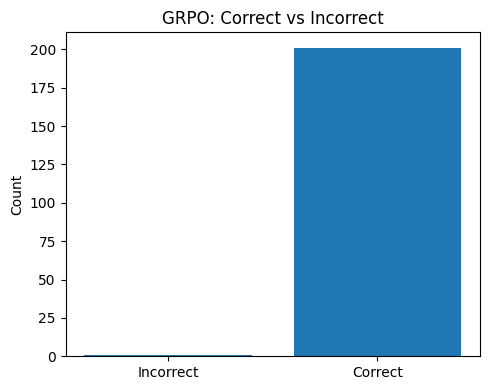

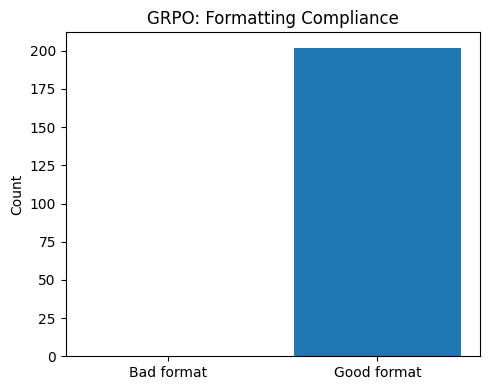

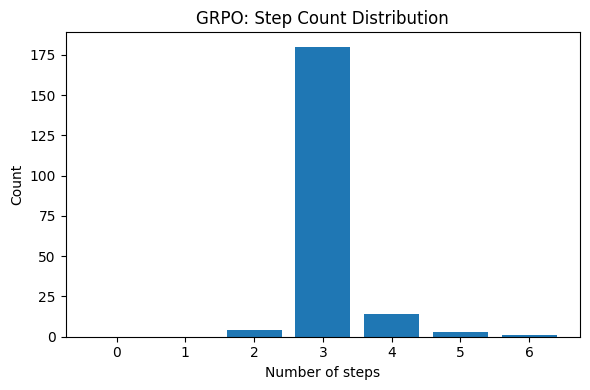

In [ ]:
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from sympy import simplify, parse_expr

# ===== CHANGE THIS EACH TIME YOU SWITCH MODELS =====
MODEL_LABEL = "GRPO"

# ===== Helper functions =====
FINAL_PAT = re.compile(r"Final:\s*(.+?)(?:\.|\n|$)", re.IGNORECASE)

def extract_final_equation(text: str):
    m = FINAL_PAT.findall(text)
    if not m:
        return None
    return m[-1].strip()

def parse_equation(eq_text: str):
    if eq_text is None or "=" not in eq_text:
        return None, None
    left, right = eq_text.split("=", 1)
    try:
        left_expr = parse_expr(left.strip(), evaluate=True)
        right_expr = parse_expr(right.strip(), evaluate=True)
        return left_expr, right_expr
    except Exception:
        return None, None

def theorem_from_prompt(prompt: str):
    # prompt format:
    # Prove the following algebraic identity:
    # <theorem>
    # Show each algebra step clearly.
    lines = prompt.split("\n")
    if len(lines) >= 2:
        return lines[1].strip()
    return ""

def clean_output(raw: str):
    clean = raw.split("Show each algebra step clearly.")[-1]
    if "Final:" in clean:
        clean = clean.split("Final:")[0] + "Final:" + clean.split("Final:")[1].split("\n")[0]
    return clean.strip()

def check_correctness(model_output: str, truth_completion: str):
    pred = extract_final_equation(model_output)
    truth = extract_final_equation(truth_completion)

    if pred is None or truth is None:
        return 0

    # exact string match
    if pred.replace(" ", "") == truth.replace(" ", ""):
        return 1

    pred_l, pred_r = parse_equation(pred)
    truth_l, truth_r = parse_equation(truth)

    if None in (pred_l, pred_r, truth_l, truth_r):
        return 0

    try:
        pred_ok = simplify(pred_l - pred_r) == 0
        truth_ok = simplify(truth_l - truth_r) == 0
        lhs_match = simplify(pred_l - truth_l) == 0
        rhs_match = simplify(pred_r - truth_r) == 0

        if pred_ok and truth_ok and lhs_match and rhs_match:
            return 1
    except Exception:
        pass

    return 0

def formatting_score(model_output: str):
    has_final = 1 if "Final:" in model_output else 0
    has_step = 1 if re.search(r"\bStep\s*\d+\s*:", model_output) else 0
    return 1 if (has_final and has_step) else 0

def step_count(model_output: str):
    return len(re.findall(r"\bStep\s*\d+\s*:", model_output))

def token_count(model_output: str):
    return len(tokenizer(model_output)["input_ids"])

# ===== Evaluate on all test identities =====
results = []

for idx, ex in enumerate(test_dataset):
    prompt = ex["prompt"]
    truth_completion = ex["completion"]

    raw = ask(prompt)
    clean = clean_output(raw)

    results.append({
        "model": MODEL_LABEL,
        "idx": idx,
        "theorem": theorem_from_prompt(prompt),
        "ground_truth": truth_completion,
        "model_output": clean,
        "correct": check_correctness(clean, truth_completion),
        "formatted": formatting_score(clean),
        "steps": step_count(clean),
        "tokens": token_count(clean),
        "has_final": 1 if extract_final_equation(clean) is not None else 0
    })

    if idx % 25 == 0:
        print(f"Finished {idx}/{len(test_dataset)}")

df = pd.DataFrame(results)

# ===== Save raw outputs =====
save_dir = "/content/drive/MyDrive/Algebra_Model"
csv_path = f"{save_dir}/{MODEL_LABEL.lower()}_test_results.csv"
df.to_csv(csv_path, index=False)
print(f"Saved raw results to: {csv_path}")

# ===== Summary metrics =====
summary = {
    "model": MODEL_LABEL,
    "n_test": len(df),
    "accuracy": df["correct"].mean(),
    "formatting_rate": df["formatted"].mean(),
    "final_rate": df["has_final"].mean(),
    "avg_steps": df["steps"].mean(),
    "avg_tokens": df["tokens"].mean(),
}

summary_df = pd.DataFrame([summary])
summary_path = f"{save_dir}/{MODEL_LABEL.lower()}_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nSUMMARY")
print(summary_df)

# ===== Plots for this one model =====
# 1. Correct vs Incorrect
plt.figure(figsize=(5,4))
counts = df["correct"].value_counts().sort_index()
plt.bar(["Incorrect", "Correct"], [counts.get(0, 0), counts.get(1, 0)])
plt.ylabel("Count")
plt.title(f"{MODEL_LABEL}: Correct vs Incorrect")
plt.tight_layout()
plt.savefig(f"{save_dir}/{MODEL_LABEL.lower()}_correctness_bar.png")
plt.show()

# 2. Formatting compliance
plt.figure(figsize=(5,4))
fmt_counts = df["formatted"].value_counts().sort_index()
plt.bar(["Bad format", "Good format"], [fmt_counts.get(0, 0), fmt_counts.get(1, 0)])
plt.ylabel("Count")
plt.title(f"{MODEL_LABEL}: Formatting Compliance")
plt.tight_layout()
plt.savefig(f"{save_dir}/{MODEL_LABEL.lower()}_formatting_bar.png")
plt.show()

# 3. Step count distribution
plt.figure(figsize=(6,4))
plt.hist(df["steps"], bins=range(0, max(df["steps"]) + 2), align="left", rwidth=0.8)
plt.xlabel("Number of steps")
plt.ylabel("Count")
plt.title(f"{MODEL_LABEL}: Step Count Distribution")
plt.tight_layout()
plt.savefig(f"{save_dir}/{MODEL_LABEL.lower()}_steps_hist.png")
plt.show()

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Algebra_Model/Data"))

['algebra_dataset.json', 'algebra_formatted.jsonl', 'ood_algebra_testset_300.json', 'ood_algebra_testset_300.jsonl']


Loaded OOD dataset: 300
Finished 0/300
Finished 25/300
Finished 50/300
Finished 75/300
Finished 100/300
Finished 125/300
Finished 150/300
Finished 175/300
Finished 200/300
Finished 225/300
Finished 250/300
Finished 275/300

OOD SUMMARY
      model  n_test  accuracy  formatting_rate  final_rate  avg_steps  \
0  GRPO_OOD     300       1.0              1.0         1.0   3.196667   

   avg_tokens  
0  105.796667  


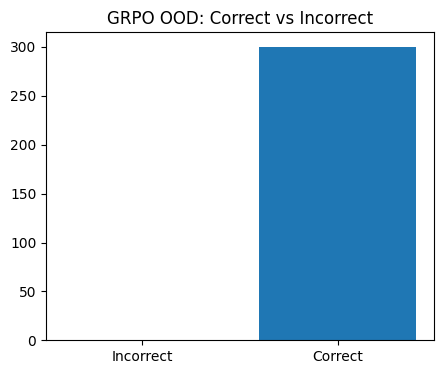

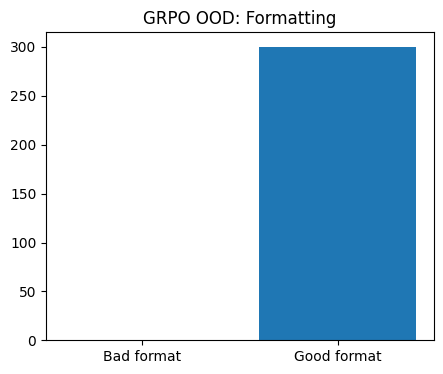

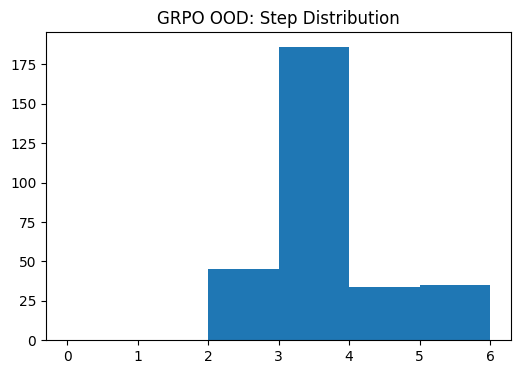

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# ===== OOD dataset path (UPDATED NAME) =====
ood_path = "/content/drive/MyDrive/Algebra_Model/Data/ood_algebra_testset_300.jsonl"

# ===== Load dataset =====
ood_dataset = load_dataset("json", data_files=ood_path, split="train")

print("Loaded OOD dataset:", len(ood_dataset))

# ===== Label =====
MODEL_LABEL = "GRPO_OOD"

# ===== Evaluation =====
results = []

for idx, ex in enumerate(ood_dataset):
    theorem = ex["theorem"]
    truth_completion = ex["proof"]
    prompt = f"Prove the following algebraic identity:\n{theorem}\nShow each algebra step clearly."

    raw = ask(prompt)
    clean = clean_output(raw)

    results.append({
        "model": MODEL_LABEL,
        "idx": idx,
        "theorem": theorem_from_prompt(prompt),
        "ground_truth": truth_completion,
        "model_output": clean,
        "correct": check_correctness(clean, truth_completion),
        "formatted": formatting_score(clean),
        "steps": step_count(clean),
        "tokens": token_count(clean),
        "has_final": 1 if extract_final_equation(clean) is not None else 0
    })

    if idx % 25 == 0:
        print(f"Finished {idx}/{len(ood_dataset)}")

df = pd.DataFrame(results)

# ===== Save results =====
save_dir = "/content/drive/MyDrive/Algebra_Model"

df.to_csv(f"{save_dir}/grpo_ood_test_results.csv", index=False)

summary = {
    "model": MODEL_LABEL,
    "n_test": len(df),
    "accuracy": df["correct"].mean(),
    "formatting_rate": df["formatted"].mean(),
    "final_rate": df["has_final"].mean(),
    "avg_steps": df["steps"].mean(),
    "avg_tokens": df["tokens"].mean(),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"{save_dir}/grpo_ood_summary.csv", index=False)

print("\nOOD SUMMARY")
print(summary_df)

# ===== Plots =====

# Correct vs Incorrect
plt.figure(figsize=(5,4))
counts = df["correct"].value_counts().sort_index()
plt.bar(["Incorrect", "Correct"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("GRPO OOD: Correct vs Incorrect")
plt.show()

# Formatting
plt.figure(figsize=(5,4))
fmt_counts = df["formatted"].value_counts().sort_index()
plt.bar(["Bad format", "Good format"], [fmt_counts.get(0, 0), fmt_counts.get(1, 0)])
plt.title("GRPO OOD: Formatting")
plt.show()

# Steps
plt.figure(figsize=(6,4))
plt.hist(df["steps"], bins=range(0, max(df["steps"]) + 2))
plt.title("GRPO OOD: Step Distribution")
plt.show()

In [ ]:
print("hi")

hi
